In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from opencv_tools import opencv_tools # 匯入封裝的功能
import os
import sys

### 20-2-5 程式範例：透過 Haar Cascade進行人臉偵測

Haar Cascade 人臉偵測結果


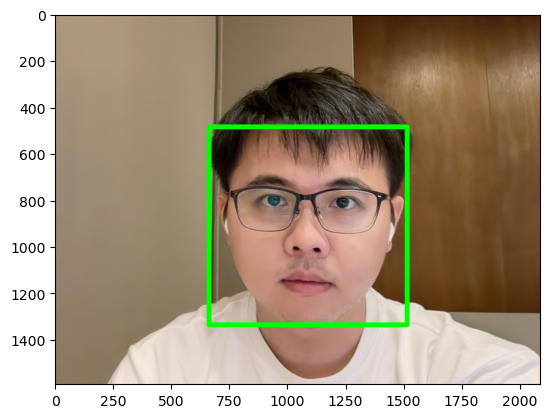

In [4]:
# 讀取原始圖片
img = cv2.imread('sample/face_sample.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 載入 Haar Cascade 分類器
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 執行人臉偵測
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# 在偵測到的人臉區域畫出方框
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 20)

print("Haar Cascade 人臉偵測結果")
opencv_tools.show_img_by_matplotlib(img)

### 20-3-6 程式範例：透過 SSD 模型進行人臉辨識

SSD 人臉偵測結果


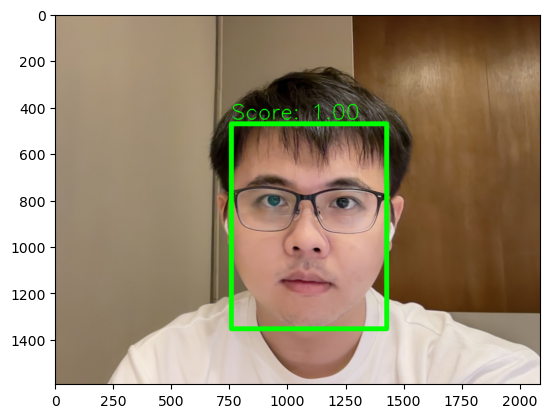

In [5]:
# 載入 DNN 模型
modelFile = "models/res10_300x300_ssd_iter_140000.caffemodel"
configFile = "models/deploy.prototxt"
net = cv2.dnn.readNetFromCaffe(configFile, modelFile)

# 讀取圖片
img = cv2.imread('sample/face_sample.jpg')
h, w = img.shape[:2]

# 前處理：將影像轉為 blob 格式
blob = cv2.dnn.blobFromImage(img, 1.0, (300, 300), (104.0, 177.0, 123.0))

# SSD 模型進行推論
net.setInput(blob)
detections = net.forward()

# 解析結果，畫出人臉方框與信心分數
for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:  # 信心度門檻
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (x1, y1, x2, y2) = box.astype("int")
        
        # 畫出人臉方框與信心分數
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 20)
        cv2.putText(img, f"Score: {confidence:.2f}", (x1, y1 - 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 3)


print("SSD 人臉偵測結果")
opencv_tools.show_img_by_matplotlib(img)

### 20-4-4 程式範例：透過 YuNet 模型進行人臉偵測

YuNet 人臉偵測結果


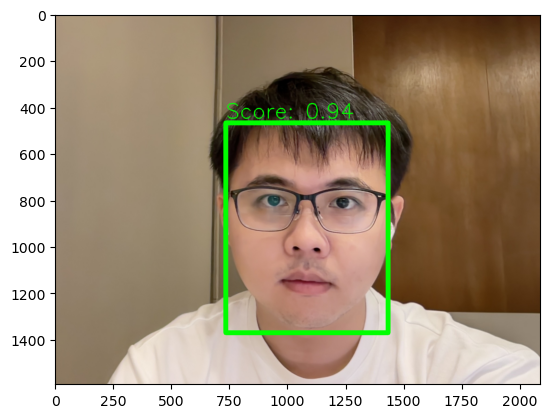

In [6]:
# 讀取圖片與前處理 (等比例縮放至寬度 640)
img = cv2.imread('sample/face_sample.jpg')
h, w = img.shape[:2]
scale = 640 / w
resized_h = int(h * scale)
resized_img = cv2.resize(img, (640, resized_h))

# 建立人臉偵測器 (填入縮放後的長寬)
detector = cv2.FaceDetectorYN.create("models/face_detection_yunet_2023mar.onnx", "", (640, resized_h))

# 執行偵測 (針對縮放後的影像)
_, faces = detector.detect(resized_img)

# 還原座標並繪製結果 (畫在原始影像上)
if faces is not None:
    for face in faces:
        # 將縮放後的座標除以 scale 還原至原圖比例，並轉為整數
        x, y, box_w, box_h = (face[:4] / scale).astype(int)
        confidence = face[14] # 取出信心度分數

        # 在原圖上畫出綠色方框與分數
        cv2.rectangle(img, (x, y), (x + box_w, y + box_h), (0, 255, 0), 20)
        cv2.putText(img, f"Score: {confidence:.2f}", (x, y - 20), 
                    cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 3)

# 5. 顯示結果
print("YuNet 人臉偵測結果")
opencv_tools.show_img_by_matplotlib(img)

## 20-E 小專案：觀察不同方法的即時人臉偵測

* 共用前處理：調整攝影機函式

In [7]:
def enhance_brightness(frame, alpha=1.2, beta=50):
    """調整影像的亮度與對比度，改善偏暗、層次不夠分明的問題。"""
    return cv2.convertScaleAbs(frame, alpha=alpha, beta=beta)

* 函式定義：Haar Cascade 方法

In [8]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_faces_haar(frame, classifier):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = classifier.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    return frame

* 函式定義：SSD 方法

In [9]:
net = cv2.dnn.readNetFromCaffe(
    "models/deploy.prototxt",
    "models/res10_300x300_ssd_iter_140000.caffemodel"
)

def detect_faces_ssd(frame, net, conf_threshold=0.5):
    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
    net.setInput(blob)
    detections = net.forward()
    
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (x1, y1, x2, y2) = box.astype("int")
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"Score: {confidence:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return frame

* 函式定義：YuNet 方法

In [10]:
detector = cv2.FaceDetectorYN.create(
    "models/face_detection_yunet_2023mar.onnx", "", (0, 0)
)

def detect_faces_yunet(frame, detector, target_width=640):
    h, w = frame.shape[:2]
    scale = target_width / w
    resized_h = int(h * scale)
    resized_frame = cv2.resize(frame, (target_width, resized_h))
    
    detector.setInputSize((target_width, resized_h))
    _, faces = detector.detect(resized_frame)
    
    if faces is not None:
        for face in faces:
            x, y, box_w, box_h = (face[:4] / scale).astype(int)
            confidence = face[14]
            cv2.rectangle(frame, (x, y), (x + box_w, y + box_h), (0, 255, 0), 2)
            cv2.putText(frame, f"Score: {confidence:.2f}", (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return frame

### 20-E-2 實測對比：不同環境下的偵測表現

In [27]:
# 載入 DNN 模型與開啟攝影機
modelFile = "models/res10_300x300_ssd_iter_140000.caffemodel"
configFile = "models/deploy.prototxt"
net = cv2.dnn.readNetFromCaffe(configFile, modelFile)
cap = cv2.VideoCapture(0)
# cap = cv2.VideoCapture("sample/video/me2.mp4") # 影片測試
# cap = cv2.VideoCapture("sample/video/me3.mp4") # 影片測試

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # 前處理（視測試需求決定是否啟用）
    # frame = enhance_brightness(frame)
    
    # === 切換人臉偵測方法（註解/取消註解切換） ===
    frame = detect_faces_haar(frame, face_cascade)
    # frame = detect_faces_ssd(frame, net)
    # frame = detect_faces_yunet(frame, detector)
    
    cv2.imshow('Face Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()